# Notebook 05 - Modeling

Notebook này tập trung vào quá trình xây dựng, huấn luyện và đánh giá các mô hình Machine Learning nhằm dự đoán mức độ Digital Burnout của người dùng dựa trên bộ đặc trưng đã được xác nhận trong Notebook 04.

Trước tiên, dữ liệu đã được làm sạch cùng danh sách các đặc trưng hợp lệ sẽ được nạp để xây dựng tập dữ liệu đầu vào cho mô hình. Sau đó, dữ liệu được chia thành tập huấn luyện, tập xác thực và tập kiểm tra, đồng thời áp dụng quy trình tiền xử lý phù hợp cho từng kiểu dữ liệu.

Nghiên cứu triển khai năm mô hình theo ba nhóm gồm Baseline Model, Primary Models và Hybrid Models. Hiệu năng của các mô hình được đánh giá thông qua nhiều chỉ số phân loại và được so sánh để lựa chọn mô hình có hiệu quả dự đoán tốt nhất.

Kết quả của notebook này sẽ là mô hình tối ưu cùng các chỉ số đánh giá tương ứng, đồng thời được sử dụng làm đầu vào cho Notebook 06 - Interpretability.

# 0. Set Up

Nhập các thư viện cần thiết, thiết lập cấu hình chung và khai báo các đường dẫn sử dụng trong notebook.

In [2]:
# Standard Library

from pathlib import Path
import warnings
import time
import joblib
import gc

# Data Manipulation

import numpy as np
import pandas as pd


# Visualization

import matplotlib.pyplot as plt
import seaborn as sns


# Machine Learning

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (

    OneHotEncoder,
    StandardScaler

)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc

)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (

    RandomForestClassifier,
    VotingClassifier,
    StackingClassifier

)

from sklearn.base import clone

# Gradient Boosting

from xgboost import XGBClassifier

warnings.filterwarnings(
    "ignore"
)

print(
    "Đã import các thư viện."
)

Đã import các thư viện.


In [3]:
# Thiết lập đường dẫn dự án

PROJECT_ROOT = (

    Path.cwd()
    .resolve()
    .parent
    .parent

)

# Thiết lập thư mục dữ liệu

data_directory = (

    PROJECT_ROOT
    / "data"
    / "processed"
    / "international_dataset"

)

# Thiết lập thư mục lưu mô hình

model_directory = (

    PROJECT_ROOT
    / "models"
    / "international_dataset"

)

model_directory.mkdir(

    parents=True,
    exist_ok=True

)

print(
    f"Đường dẫn dự án: {PROJECT_ROOT}"
)

print(
    f"Thư mục dữ liệu: {data_directory}"
)

print(
    f"Thư mục lưu mô hình: {model_directory}"
)

Đường dẫn dự án: D:\DA016
Thư mục dữ liệu: D:\DA016\data\processed\international_dataset
Thư mục lưu mô hình: D:\DA016\models\international_dataset


In [4]:
# Thiết lập tham số chung

RANDOM_STATE = 42
TARGET_VARIABLE = "burnout_level"
TEST_SIZE = 0.15
VALIDATION_SIZE = 0.15
GPU_AVAILABLE = True

print(
    f"Random State: {RANDOM_STATE}"
)

print(
    f"Target Variable: {TARGET_VARIABLE}"
)

Random State: 42
Target Variable: burnout_level


In [5]:
# Kiểm tra khả năng sử dụng GPU của XGBoost

try:

    from xgboost import build_info

    GPU_AVAILABLE = build_info().get(
        "USE_CUDA",
        False

    )

except Exception:

    GPU_AVAILABLE = False

if GPU_AVAILABLE:

    print(
        "Đã phát hiện GPU NVIDIA hỗ trợ CUDA."
    )

else:

    print(
        "Không phát hiện GPU CUDA. XGBoost sẽ sử dụng CPU."
    )

Đã phát hiện GPU NVIDIA hỗ trợ CUDA.


# 1. Data Preparation

Section này chuẩn bị dữ liệu đầu vào cho quá trình xây dựng mô hình Machine Learning. Bộ dữ liệu đã được tiền xử lý cùng danh sách các đặc trưng đã được xác nhận từ Notebook 04 sẽ được sử dụng để xây dựng ma trận đặc trưng và biến mục tiêu. Đồng thời, các đặc trưng cũng được phân loại theo kiểu dữ liệu nhằm phục vụ cho quy trình tiền xử lý và huấn luyện các mô hình ở các bước tiếp theo.

## 1.1 Load Cleaned Dataset

Nạp bộ dữ liệu đã được tiền xử lý và kiểm tra thông tin tổng quan trước khi xây dựng mô hình.

In [6]:
# Thiết lập đường dẫn dữ liệu

cleaned_data_path = (

    data_directory
    / "digital_burnout_cleaned.csv"

)

# Đọc bộ dữ liệu đã tiền xử lý

df = pd.read_csv(
    cleaned_data_path
)

print(
    "Đã nạp bộ dữ liệu."
)

display(

    pd.DataFrame({

        "Thông tin": [

            "Số lượng bản ghi",
            "Số lượng thuộc tính"

        ],

        "Giá trị": [

            df.shape[0],
            df.shape[1]

        ]

    })

)

Đã nạp bộ dữ liệu.


,Thông tin,Giá trị
0,Số lượng bản ghi,5000000
1,Số lượng thuộc tính,35


## 1.2 Load Validated Features

Nạp danh sách các đặc trưng đã được xác nhận từ Notebook 04 nhằm đảm bảo các mô hình chỉ sử dụng những biến nghiên cứu đã được lựa chọn.

In [7]:
# Thiết lập đường dẫn danh sách đặc trưng

validated_feature_path = (

    data_directory
    / "validated_features.csv"

)

# Đọc danh sách đặc trưng

validated_features = pd.read_csv(
    validated_feature_path
)

print(
    "Đã nạp danh sách đặc trưng."
)

display(
    validated_features
)

Đã nạp danh sách đặc trưng.


,Final Rank,Feature,Feature Category
0,1,emotional_exhaustion,Primary Feature
1,2,stress_level,Primary Feature
2,3,daily_screen_time,Primary Feature
3,4,doomscrolling_duration,Primary Feature
4,5,distraction_frequency,Primary Feature
5,6,sleep_hours,Primary Feature
6,7,notification_count,Primary Feature
7,8,late_night_device_usage,Secondary Feature
8,9,deep_work_hours,Secondary Feature
9,10,focus_sessions,Secondary Feature


## 1.3 Define Feature Matrix and Target

Xây dựng ma trận đặc trưng, biến mục tiêu và phân loại các đặc trưng theo kiểu dữ liệu để chuẩn bị cho quá trình chia dữ liệu và xây dựng pipeline tiền xử lý.

In [8]:
# Trích xuất danh sách đặc trưng

modeling_features = (

    validated_features["Feature"]
    .tolist()

)

# Xây dựng ma trận đặc trưng

X = df[
    modeling_features
].copy()

# Mã hóa biến mục tiêu

label_mapping = {

    "Low": 0,
    "Moderate": 1,
    "High": 2

}

y = (

    df[TARGET_VARIABLE]
    .map(label_mapping)

)

# Phân loại đặc trưng theo kiểu dữ liệu

numerical_features = [

    feature
    for feature in modeling_features
    if X[feature].dtype != "object"

]

categorical_features = [

    feature
    for feature in modeling_features
    if X[feature].dtype == "object"

]

print(
    "Đã xây dựng ma trận đặc trưng và biến mục tiêu."
)

display(

    pd.DataFrame({

        "Thông tin": [

            "Tổng số đặc trưng",
            "Số đặc trưng số",
            "Số đặc trưng phân loại",
            "Biến mục tiêu"

        ],

        "Giá trị": [

            len(modeling_features),
            len(numerical_features),
            len(categorical_features),
            TARGET_VARIABLE

        ]

    })

)

Đã xây dựng ma trận đặc trưng và biến mục tiêu.


,Thông tin,Giá trị
0,Tổng số đặc trưng,20
1,Số đặc trưng số,18
2,Số đặc trưng phân loại,2
3,Biến mục tiêu,burnout_level


## 1.4 Train / Validation / Test Split

Dữ liệu ban đầu được chia thành tập huấn luyện (70%), tập xác thực (15%) và tập kiểm tra (15%). Để phù hợp với giới hạn phần cứng và tối ưu thời gian huấn luyện, một tập mẫu gồm 1.000.000 quan sát được lấy ngẫu nhiên có phân tầng từ tập huấn luyện ban đầu. Tập xác thực và tập kiểm tra được giữ nguyên nhằm đảm bảo tính nhất quán và độ tin cậy trong quá trình đánh giá mô hình.

In [9]:
# Chia tập dữ liệu thành tập huấn luyện, xác thực và kiểm tra

X_train_full, X_temp, y_train_full, y_temp = train_test_split(

    X,
    y,
    train_size=0.70,
    stratify=y,
    random_state=RANDOM_STATE

)

X_validation, X_test, y_validation, y_test = train_test_split(

    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE

)

# Lấy mẫu ngẫu nhiên có phân tầng cho tập huấn luyện

X_train, _, y_train, _ = train_test_split(

    X_train_full,
    y_train_full,
    train_size=1_000_000,
    stratify=y_train_full,
    random_state=RANDOM_STATE

)

split_summary = pd.DataFrame(

    {

        "Tập dữ liệu": [

            "Huấn luyện",
            "Xác thực",
            "Kiểm tra"

        ],

        "Số lượng mẫu": [

            len(X_train),
            len(X_validation),
            len(X_test)

        ]

    }

)

split_summary["Tỷ lệ (%)"] = (

    split_summary["Số lượng mẫu"]
    /
    len(df)
    *
    100
    
).round(2)

display(split_summary)

,Tập dữ liệu,Số lượng mẫu,Tỷ lệ (%)
0,Huấn luyện,1000000,20.0
1,Xác thực,750000,15.0
2,Kiểm tra,750000,15.0


In [10]:
# Kiểm tra phân bố biến mục tiêu

distribution_summary = pd.DataFrame({

    "Train": y_train.value_counts(normalize=True),
    "Validation": y_validation.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)

}).round(4)

display(
    distribution_summary
)

,Train,Validation,Test
burnout_level,,,
1,0.5286,0.5286,0.5286
0,0.2560,0.2560,0.2560
2,0.2154,0.2154,0.2154


## 1.5 Build Preprocessing Pipeline

Xây dựng Pipeline tiền xử lý dữ liệu nhằm chuẩn hóa quy trình biến đổi dữ liệu đầu vào trước khi huấn luyện mô hình. Các đặc trưng số và đặc trưng phân loại sẽ được xử lý riêng biệt thông qua `ColumnTransformer`, đảm bảo cùng một quy trình tiền xử lý được áp dụng nhất quán cho tất cả các mô hình trong nghiên cứu.

In [11]:
# Pipeline xử lý đặc trưng số

numerical_pipeline = Pipeline(

    steps=[

        (
            "scaler",
            StandardScaler()
        )

    ]

)

# Pipeline xử lý đặc trưng phân loại

categorical_pipeline = Pipeline(

    steps=[

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
            )
        )

    ]

)

# Kết hợp hai pipeline

preprocessing_pipeline = ColumnTransformer(

    transformers=[

        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )

    ],

    remainder="drop"

)

print(
    "Đã xây dựng Pipeline tiền xử lý."
)

display(

    pd.DataFrame({

        "Pipeline": [

            "Đặc trưng số",
            "Đặc trưng phân loại"

        ],

        "Phương pháp": [

            "StandardScaler",
            "OneHotEncoder"

        ]

    })

)

Đã xây dựng Pipeline tiền xử lý.


,Pipeline,Phương pháp
0,Đặc trưng số,StandardScaler
1,Đặc trưng phân loại,OneHotEncoder


# 2. Model Development

Section này xây dựng các mô hình Machine Learning phục vụ dự đoán mức độ Digital Burnout. Nghiên cứu lần lượt phát triển mô hình cơ sở (Baseline Model), các mô hình chính (Primary Models) và các mô hình kết hợp (Hybrid Models). Toàn bộ quá trình huấn luyện được tối ưu nhằm giảm thời gian xử lý, hạn chế sử dụng bộ nhớ và tận dụng khả năng tăng tốc bằng GPU đối với các mô hình có hỗ trợ.

## 2.1 Model Selection

Khởi tạo các mô hình Machine Learning sử dụng trong nghiên cứu. Các tham số được lựa chọn nhằm cân bằng giữa hiệu quả dự đoán, tốc độ huấn luyện và khả năng xử lý tập dữ liệu lớn.

In [12]:
# Khởi tạo mô hình Baseline

baseline_model = LogisticRegression(

    solver="saga",
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1

)

# Khởi tạo mô hình Random Forest

random_forest_model = RandomForestClassifier(

    n_estimators=150,
    max_depth=20,
    max_samples=0.7,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE

)

# Khởi tạo mô hình XGBoost

xgboost_parameters = {

    "objective": "multi:softprob",
    "num_class": len(label_mapping),
    "eval_metric": "mlogloss",
    "random_state": RANDOM_STATE,
    "tree_method": "hist",
    "max_depth": 7,
    "learning_rate": 0.10,
    "n_estimators": 250,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "max_bin": 256

}

# Kích hoạt GPU nếu khả dụng

if GPU_AVAILABLE:

    xgboost_parameters["device"] = "cuda"

else:

    xgboost_parameters["device"] = "cpu"

xgboost_model = XGBClassifier(

    **xgboost_parameters

)

print(
    "Đã khởi tạo các mô hình Machine Learning."
)

display(

    pd.DataFrame({

        "Mô hình": [

            "Logistic Regression",
            "Random Forest",
            "XGBoost"

        ],

        "Vai trò": [

            "Baseline",
            "Primary",
            "Primary"

        ]

    })

)

Đã khởi tạo các mô hình Machine Learning.


,Mô hình,Vai trò
0,Logistic Regression,Baseline
1,Random Forest,Primary
2,XGBoost,Primary


## 2.2 Model Training Function

Xây dựng hàm huấn luyện dùng chung cho tất cả các mô hình Machine Learning. Hàm này thực hiện thống nhất quy trình tiền xử lý dữ liệu, huấn luyện mô hình, lưu mô hình, ghi nhận thời gian thực thi và giải phóng bộ nhớ sau mỗi lần huấn luyện nhằm tối ưu hiệu năng đối với tập dữ liệu lớn.

In [13]:
# Hàm huấn luyện mô hình

def train_model(

    model,
    X_train,
    y_train

):

    start_time = time.time()

    pipeline = Pipeline(

        steps=[

            (
                "preprocessing",
                preprocessing_pipeline
            ),

            (
                "model",
                model
            )

        ]

    )

    pipeline.fit(
        X_train,
        y_train
    )

    training_time = (
        time.time()
        -
        start_time
    )

    return (
        pipeline,
        training_time
    )

In [14]:
# Hàm đánh giá mô hình

def evaluate_model(

    pipeline,
    X_validation,
    y_validation,
    model_name,
    training_time

):

    prediction = pipeline.predict(
        X_validation
    )

    probability = pipeline.predict_proba(
        X_validation
    )

    results = pd.DataFrame(

        {

            "Model": [
                model_name
            ],
            "Accuracy": [

                accuracy_score(

                    y_validation,
                    prediction

                )

            ],

            "Precision": [

                precision_score(

                    y_validation,
                    prediction,
                    average="weighted"

                )

            ],

            "Recall": [

                recall_score(

                    y_validation,
                    prediction,
                    average="weighted"

                )

            ],

            "F1 Score": [

                f1_score(

                    y_validation,
                    prediction,
                    average="weighted"

                )

            ],

            "ROC AUC": [

                roc_auc_score(

                    y_validation,
                    probability,
                    multi_class="ovr",
                    average="weighted"

                )

            ],

            "Training Time (s)": [
                training_time

            ]

        }

    )

    confusion = confusion_matrix(

        y_validation,
        prediction

    )

    report = classification_report(

        y_validation,
        prediction,
        output_dict=True

    )

    return (

        results,
        confusion,
        report

    )

In [15]:
# Hàm lưu mô hình

def save_model(

    pipeline,
    model_name

):

    model_path = (

        model_directory
        / f"{model_name}.joblib"

    )

    joblib.dump(

        pipeline,
        model_path

    )

    return model_path

In [16]:
# Hàm giải phóng bộ nhớ

def release_memory(
    *objects
):

    for obj in objects:
        del obj
    gc.collect()

## 2.3 Train Baseline Model

Huấn luyện mô hình Logistic Regression làm mô hình cơ sở (Baseline Model) của nghiên cứu. Kết quả từ mô hình này đóng vai trò làm mốc tham chiếu để đánh giá mức độ cải thiện của các mô hình nâng cao trong các bước tiếp theo.

In [17]:
# Huấn luyện mô hình Logistic Regression

print(
    "Đang huấn luyện Logistic Regression..."
)

logistic_pipeline, logistic_training_time = train_model(

    model=baseline_model,
    X_train=X_train,
    y_train=y_train

)

logistic_results, logistic_confusion_matrix, logistic_report = evaluate_model(

    pipeline=logistic_pipeline,
    X_validation=X_validation,
    y_validation=y_validation,
    model_name="Logistic Regression",
    training_time=logistic_training_time

)

logistic_model_path = save_model(

    pipeline=logistic_pipeline,
    model_name="logistic_regression"

)

display(
    logistic_results
)

Đang huấn luyện Logistic Regression...


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
0,Logistic Regression,0.671804,0.675189,0.671804,0.665584,0.7925,182.518699


In [18]:
# Giải phóng bộ nhớ

release_memory(
    logistic_pipeline
)

print(
    "Đã giải phóng bộ nhớ."
)

Đã giải phóng bộ nhớ.


## 2.4 Train Primary Models

Huấn luyện các mô hình Machine Learning chính được lựa chọn trong nghiên cứu, bao gồm Random Forest và XGBoost. Đây là hai mô hình có khả năng học các mối quan hệ phi tuyến và được kỳ vọng cải thiện hiệu quả dự đoán so với mô hình Baseline.

### Random Forest

Mô hình Random Forest được lựa chọn làm mô hình học máy chính nhờ khả năng xử lý dữ liệu có nhiều đặc trưng, giảm hiện tượng overfitting thông qua cơ chế Bagging và cung cấp độ quan trọng của đặc trưng (Feature Importance). Đồng thời, mô hình hỗ trợ xử lý đa luồng giúp rút ngắn thời gian huấn luyện trên tập dữ liệu lớn.

In [19]:
# Huấn luyện mô hình Random Forest

print(
    "Đang huấn luyện Random Forest..."
)

random_forest_pipeline, random_forest_training_time = train_model(

    model=random_forest_model,
    X_train=X_train,
    y_train=y_train

)

random_forest_results, random_forest_confusion_matrix, random_forest_report = evaluate_model(

    pipeline=random_forest_pipeline,
    X_validation=X_validation,
    y_validation=y_validation,
    model_name="Random Forest",
    training_time=random_forest_training_time

)

random_forest_model_path = save_model(

    pipeline=random_forest_pipeline,
    model_name="random_forest"

)

display(
    random_forest_results
)

Đang huấn luyện Random Forest...


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
0,Random Forest,0.66478,0.6756,0.66478,0.652512,0.783796,105.705464


In [20]:
release_memory(
    random_forest_pipeline
)

print(
    "Đã giải phóng bộ nhớ."
)

Đã giải phóng bộ nhớ.


### XGBoost

XGBoost được lựa chọn là mô hình học máy chính nhờ khả năng tối ưu hóa Gradient Boosting, xử lý hiệu quả tập dữ liệu lớn và hỗ trợ tăng tốc bằng GPU thông qua CUDA. Mô hình được kỳ vọng đạt hiệu năng dự đoán cao nhất trong nghiên cứu và đóng vai trò là mô hình tham chiếu cho các mô hình kết hợp ở các bước tiếp theo.

In [21]:
# Huấn luyện mô hình XGBoost

print(
    "Đang huấn luyện XGBoost..."
)

xgboost_pipeline, xgboost_training_time = train_model(

    model=xgboost_model,
    X_train=X_train,
    y_train=y_train

)

xgboost_results, xgboost_confusion_matrix, xgboost_report = evaluate_model(

    pipeline=xgboost_pipeline,
    X_validation=X_validation,
    y_validation=y_validation,
    model_name="XGBoost",
    training_time=xgboost_training_time

)

xgboost_model_path = save_model(

    pipeline=xgboost_pipeline,
    model_name="xgboost"

)

display(
    xgboost_results
)

Đang huấn luyện XGBoost...


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
0,XGBoost,0.671688,0.675551,0.671688,0.665066,0.791603,15.473453


In [22]:
# Giải phóng bộ nhớ

release_memory(
    xgboost_pipeline
)

print(
    "Đã giải phóng bộ nhớ."
)

Đã giải phóng bộ nhớ.


## 2.5 Train Hybrid Models

Huấn luyện các mô hình kết hợp (Hybrid Models) nhằm tận dụng ưu điểm của nhiều thuật toán Machine Learning khác nhau. Hai phương pháp được lựa chọn bao gồm Voting Classifier và Stacking Classifier nhằm đánh giá khả năng cải thiện hiệu năng dự đoán so với các mô hình đơn lẻ.

### Voting Classifier

Voting Classifier kết hợp dự đoán của nhiều mô hình cơ sở thông qua cơ chế bỏ phiếu mềm (Soft Voting). Xác suất dự đoán của từng mô hình được tổng hợp để đưa ra kết quả cuối cùng, giúp giảm sai số và tăng tính ổn định của mô hình.

In [23]:
# Khởi tạo mô hình Voting Classifier

voting_model = VotingClassifier(

    estimators=[

        (
            "logistic",
            baseline_model
        ),

        (
            "random_forest",
            random_forest_model
        ),

        (
            "xgboost",
            xgboost_model
        )

    ],

    voting="soft",
    n_jobs=-1

)

In [24]:
# Huấn luyện Voting Classifier

print(
    "Đang huấn luyện Voting Classifier..."
)

voting_pipeline, voting_training_time = train_model(

    model=voting_model,
    X_train=X_train,
    y_train=y_train

)

voting_results, voting_confusion_matrix, voting_report = evaluate_model(

    pipeline=voting_pipeline,
    X_validation=X_validation,
    y_validation=y_validation,
    model_name="Voting Classifier",
    training_time=voting_training_time

)

voting_model_path = save_model(

    pipeline=voting_pipeline,
    model_name="voting_classifier"

)

display(
    voting_results
)

Đang huấn luyện Voting Classifier...


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
0,Voting Classifier,0.671733,0.677284,0.671733,0.663843,0.792146,278.159856


In [25]:
release_memory(
    voting_pipeline
)

print(
    "Đã giải phóng bộ nhớ."
)

Đã giải phóng bộ nhớ.


### Stacking Classifier

Stacking Classifier là mô hình kết hợp sử dụng nhiều mô hình cơ sở để tạo ra các dự đoán trung gian, sau đó sử dụng một mô hình học máy ở tầng cuối (Meta Learner) để đưa ra dự đoán cuối cùng. Phương pháp này tận dụng được ưu điểm của từng mô hình cơ sở, đồng thời học cách kết hợp chúng nhằm cải thiện khả năng tổng quát hóa và nâng cao hiệu quả dự đoán trên dữ liệu chưa từng quan sát.

In [26]:
# Khởi tạo mô hình Stacking Classifier

stacking_model = StackingClassifier(

    estimators=[

        (
            "logistic",
            baseline_model
        ),

        (
            "random_forest",
            random_forest_model
        ),

        (
            "xgboost",
            xgboost_model
        )

    ],

    final_estimator=LogisticRegression(

        max_iter=1000,
        random_state=RANDOM_STATE

    ),

    cv=5,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=-1

)

In [27]:
# Huấn luyện Stacking Classifier

print(
    "Đang huấn luyện Stacking Classifier..."
)

stacking_pipeline, stacking_training_time = train_model(
    model=stacking_model,
    X_train=X_train,
    y_train=y_train

)

stacking_results, stacking_confusion_matrix, stacking_report = evaluate_model(

    pipeline=stacking_pipeline,
    X_validation=X_validation,
    y_validation=y_validation,
    model_name="Stacking Classifier",
    training_time=stacking_training_time

)

stacking_model_path = save_model(

    pipeline=stacking_pipeline,
    model_name="stacking_classifier"

)

display(
    stacking_results
)

Đang huấn luyện Stacking Classifier...


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
0,Stacking Classifier,0.671839,0.673559,0.671839,0.66696,0.793057,829.482271


In [46]:
release_memory(
    stacking_pipeline
)

print(
    "Đã giải phóng bộ nhớ."
)

Đã giải phóng bộ nhớ.


# 3. Model Evaluation

Đánh giá và so sánh hiệu quả dự đoán của các mô hình Machine Learning đã được huấn luyện thông qua các chỉ số đánh giá thống nhất. Kết quả được sử dụng để xác định mô hình có hiệu năng tốt nhất nhằm phục vụ cho giai đoạn diễn giải mô hình và xây dựng hệ thống Digital Burnout Prediction.

## 3.1 Model Performance Comparison

Tổng hợp các chỉ số đánh giá của toàn bộ mô hình nhằm so sánh hiệu năng dự đoán trên cùng một tập dữ liệu xác thực. Các chỉ số được sử dụng bao gồm Accuracy, Precision, Recall, F1 Score, ROC AUC và thời gian huấn luyện.

In [29]:
# Tổng hợp kết quả đánh giá mô hình

model_performance = pd.concat(

    [

        logistic_results,
        random_forest_results,
        xgboost_results,
        voting_results,
        stacking_results

    ],

    ignore_index=True

)

model_performance = model_performance.sort_values(

    by=[

        "Accuracy",
        "ROC AUC"

    ],

    ascending=False

).reset_index(
    drop=True
)

display(
    model_performance
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
0,Stacking Classifier,0.671839,0.673559,0.671839,0.666960,0.793057,829.482271
1,Logistic Regression,0.671804,0.675189,0.671804,0.665584,0.792500,182.518699
2,Voting Classifier,0.671733,0.677284,0.671733,0.663843,0.792146,278.159856
3,XGBoost,0.671688,0.675551,0.671688,0.665066,0.791603,15.473453
4,Random Forest,0.664780,0.675600,0.664780,0.652512,0.783796,105.705464


In [30]:
# Lưu bảng kết quả đánh giá mô hình

model_performance.to_csv(

    model_directory
    / "model_performance.csv",
    index=False

)

In [31]:
# Hiển thị mô hình có hiệu năng tốt nhất

best_model = model_performance.iloc[0]

print(
    f"Mô hình tốt nhất: {best_model['Model']}"
)

print(
    f"Accuracy: {best_model['Accuracy']:.4f}"
)

print(
    f"ROC AUC: {best_model['ROC AUC']:.4f}"
)

Mô hình tốt nhất: Stacking Classifier
Accuracy: 0.6718
ROC AUC: 0.7931


## 3.2 Confusion Matrix

Trực quan hóa kết quả phân loại của từng mô hình thông qua Confusion Matrix nhằm quan sát số lượng dự đoán đúng và dự đoán sai giữa các mức độ Digital Burnout. Ma trận nhầm lẫn giúp đánh giá khả năng phân biệt giữa các lớp Low, Moderate và High của từng mô hình trên tập dữ liệu xác thực.

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

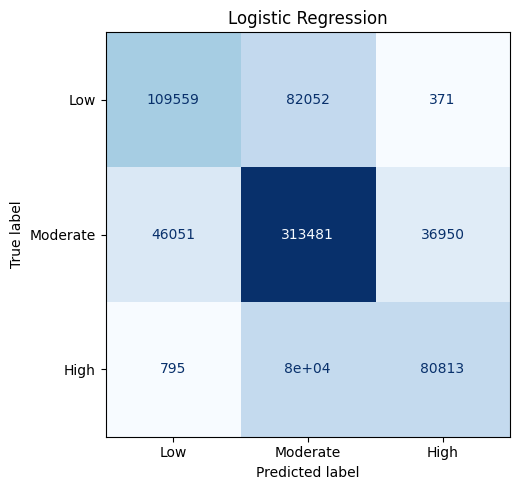

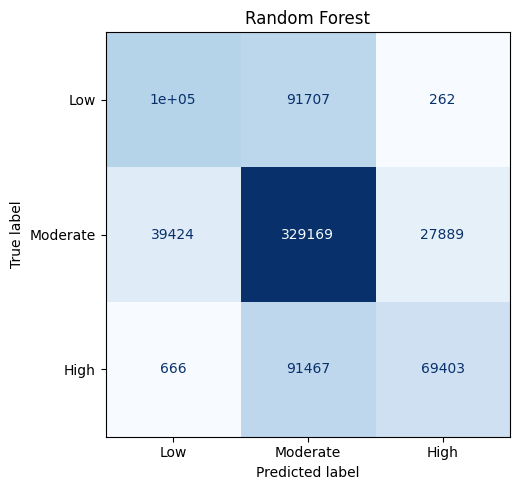

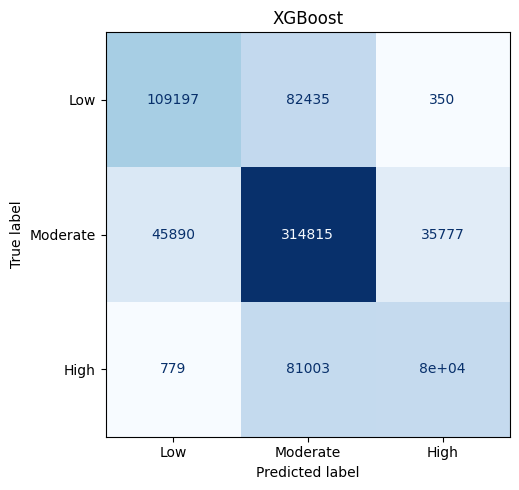

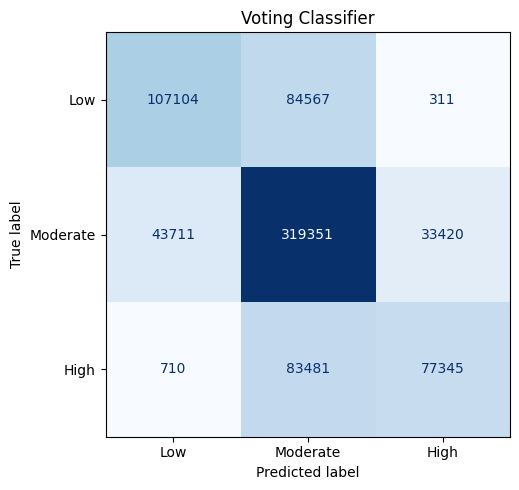

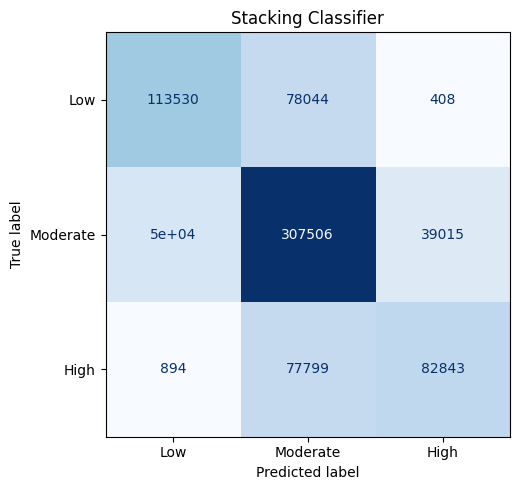

In [33]:
# Hiển thị Confusion Matrix của các mô hình

model_confusion_matrices = [

    (
        "Logistic Regression",
        logistic_confusion_matrix
    ),

    (
        "Random Forest",
        random_forest_confusion_matrix
    ),

    (
        "XGBoost",
        xgboost_confusion_matrix
    ),

    (
        "Voting Classifier",
        voting_confusion_matrix
    ),

    (
        "Stacking Classifier",
        stacking_confusion_matrix
    )

]

for model_name, confusion_matrix in model_confusion_matrices:

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    ConfusionMatrixDisplay(

        confusion_matrix=confusion_matrix,

        display_labels=[
            "Low",
            "Moderate",
            "High"
        ]

    ).plot(

        cmap="Blues",
        ax=ax,
        colorbar=False

    )

    ax.set_title(
        f"{model_name}"
    )

    plt.tight_layout()

    plt.show()

## 3.3 ROC Curve

So sánh khả năng phân biệt giữa các mức độ Digital Burnout của các mô hình thông qua đường cong Receiver Operating Characteristic (ROC) và chỉ số Area Under the Curve (ROC AUC). Đối với bài toán phân loại đa lớp, ROC Curve được xây dựng theo phương pháp One-vs-Rest (OvR).

In [34]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

In [35]:
# Chuyển nhãn sang dạng One-vs-Rest

y_validation_binarized = label_binarize(
    y_validation,
    classes=np.arange(len(label_mapping))
)

In [36]:
# Hàm hiển thị ROC Curve

def plot_roc_curve(
    pipeline,
    model_name
):

    probability = pipeline.predict_proba(
        X_validation
    )

    plt.figure(
        figsize=(7, 6)
    )

    for class_index, class_name in enumerate(

        [
            "Low",
            "Moderate",
            "High"
        ]

    ):

        fpr, tpr, _ = roc_curve(

            y_validation_binarized[:, class_index],
            probability[:, class_index]

        )

        roc_auc = auc(

            fpr,
            tpr

        )

        plt.plot(

            fpr,
            tpr,
            label=f"{class_name} (AUC = {roc_auc:.3f})"

        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray"
    )

    plt.title(
        model_name
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

In [37]:
logistic_pipeline = joblib.load(
    model_directory / "logistic_regression.joblib"
)

random_forest_pipeline = joblib.load(
    model_directory / "random_forest.joblib"
)

xgboost_pipeline = joblib.load(
    model_directory / "xgboost.joblib"
)

voting_pipeline = joblib.load(
    model_directory / "voting_classifier.joblib"
)

stacking_pipeline = joblib.load(
    model_directory / "stacking_classifier.joblib"
)

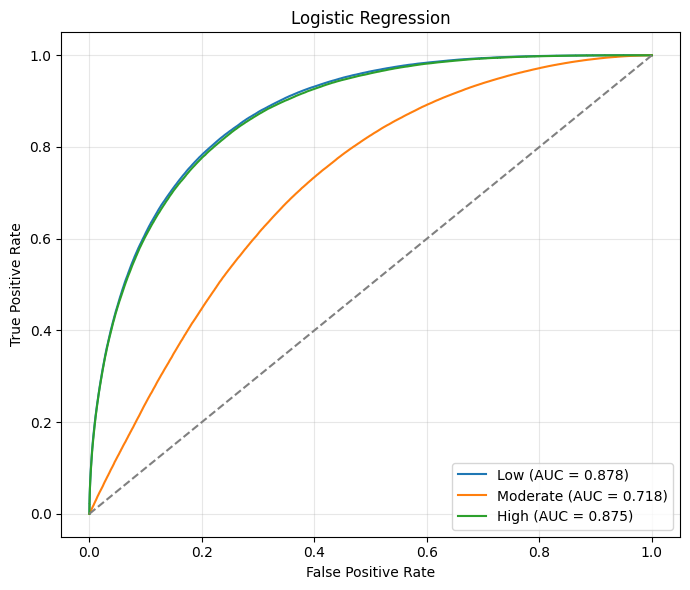

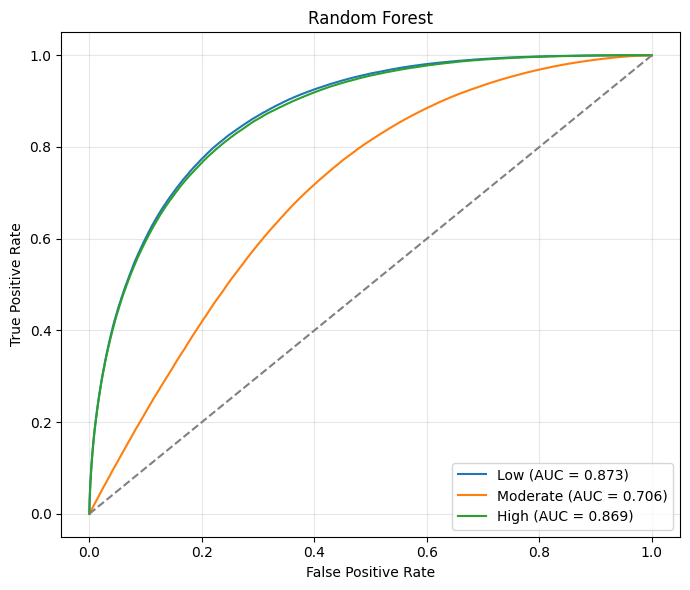

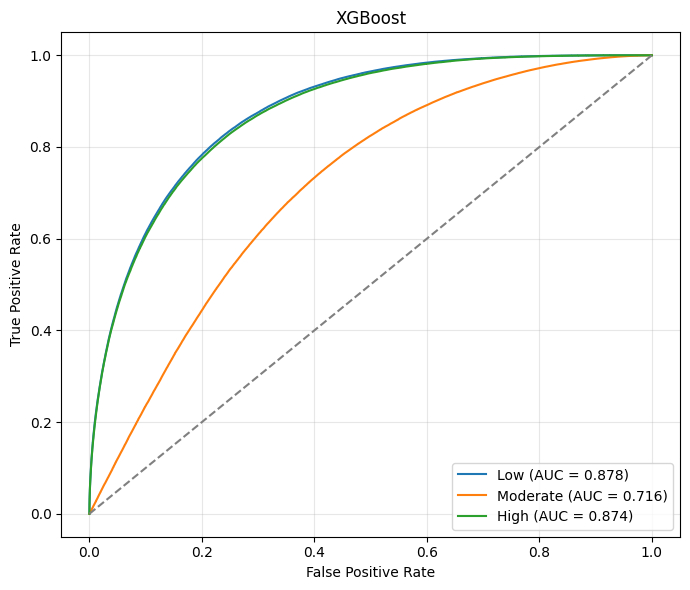

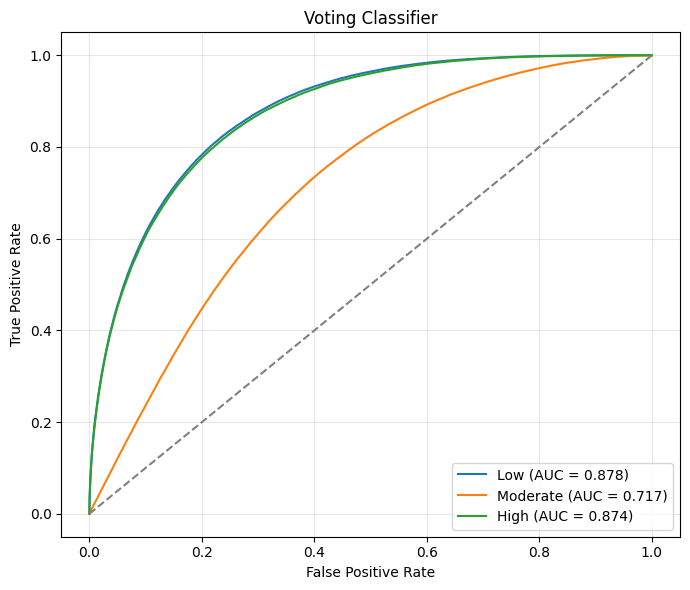

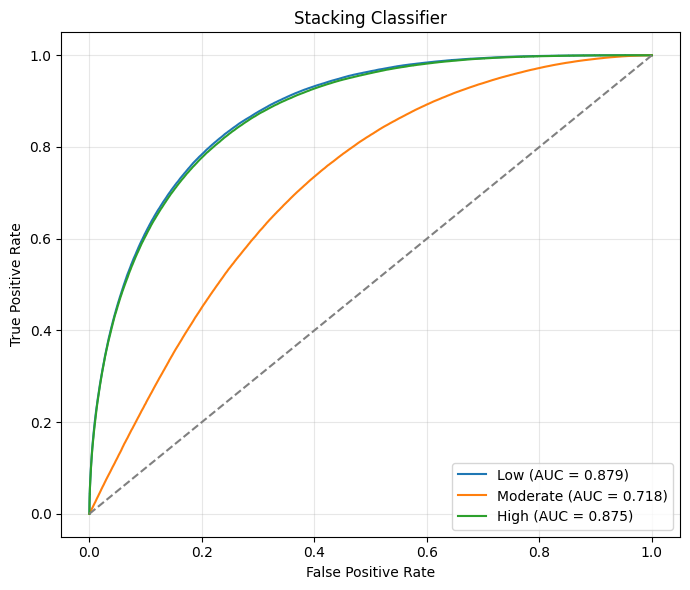

In [38]:
plot_roc_curve(
    logistic_pipeline,
    "Logistic Regression"
)

plot_roc_curve(
    random_forest_pipeline,
    "Random Forest"
)

plot_roc_curve(
    xgboost_pipeline,
    "XGBoost"
)

plot_roc_curve(
    voting_pipeline,
    "Voting Classifier"
)

plot_roc_curve(
    stacking_pipeline,
    "Stacking Classifier"
)

In [39]:
confusion_matrices = {

    "Logistic Regression": logistic_confusion_matrix,
    "Random Forest": random_forest_confusion_matrix,
    "XGBoost": xgboost_confusion_matrix,
    "Voting Classifier": voting_confusion_matrix,
    "Stacking Classifier": stacking_confusion_matrix

}

joblib.dump(

    confusion_matrices,
    model_directory / "confusion_matrices.joblib"

)

['D:\\DA016\\models\\international_dataset\\confusion_matrices.joblib']

## 3.4 Best Model Selection

Lựa chọn mô hình có hiệu năng tổng thể tốt nhất dựa trên các chỉ số đánh giá đã tổng hợp. Mô hình được lựa chọn sẽ được sử dụng trong Notebook 06 để thực hiện diễn giải mô hình (Model Interpretability) và phân tích các yếu tố ảnh hưởng đến Digital Burnout.

In [40]:
# Lựa chọn mô hình tốt nhất

best_model_name = model_performance.iloc[0]["Model"]

print(
    f"Mô hình được lựa chọn: {best_model_name}"
)

Mô hình được lựa chọn: Stacking Classifier


In [41]:
# Xác định pipeline của mô hình tốt nhất

model_dictionary = {

    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgboost_pipeline,
    "Voting Classifier": voting_pipeline,
    "Stacking Classifier": stacking_pipeline

}

best_pipeline = model_dictionary[best_model_name]

In [42]:
# Lưu mô hình tốt nhất

best_model_path = save_model(

    pipeline=best_pipeline,
    model_name="best_model"

)

print(
    f"Đã lưu mô hình tốt nhất tại:\n{best_model_path}"
)

Đã lưu mô hình tốt nhất tại:
D:\DA016\models\international_dataset\best_model.joblib


### Interpretability Model

Mặc dù mô hình Stacking Classifier đạt hiệu suất dự báo cao nhất, mô hình XGBoost vẫn được lựa chọn nhằm phục vụ cho việc giải thích mô hình trong các phân tích tiếp theo. XGBoost hỗ trợ tích cực cơ chế SHAP, giúp việc xác định đóng góp thuộc tính (feature attribution) ở cả cấp độ toàn cục và cục bộ trở nên hiệu quả và đáng tin cậy hơn, trong khi vẫn duy trì được hiệu suất dự báo cạnh tranh."

# 4. Export Results

Lưu toàn bộ kết quả huấn luyện và đánh giá mô hình để phục vụ cho các bước phân tích, diễn giải mô hình và xây dựng hệ thống Digital Burnout Prediction trong các notebook tiếp theo.

In [43]:
# Xuất bảng đánh giá mô hình

model_performance.to_csv(

    model_directory
    / "model_performance.csv",
    index=False

)

In [44]:
# Xuất Classification Report

classification_reports = {

    "Logistic Regression": logistic_report,
    "Random Forest": random_forest_report,
    "XGBoost": xgboost_report,
    "Voting Classifier": voting_report,
    "Stacking Classifier": stacking_report

}

joblib.dump(

    classification_reports,
    model_directory
    / "classification_reports.joblib"

)

['D:\\DA016\\models\\international_dataset\\classification_reports.joblib']

In [45]:
joblib.dump(
    X_validation,
    model_directory / "X_validation.joblib"
)

joblib.dump(
    y_validation,
    model_directory / "y_validation.joblib"
)

['D:\\DA016\\models\\international_dataset\\y_validation.joblib']